# Multi-objective Diet Optimization — main experiment notebook

This notebook runs the **end-to-end experimental pipeline** for the BAO group project: load the dataset, tune algorithm hyperparameters, run the final benchmark grid, then regenerate the tables/plots used in the report.

**Pipeline (high level)**
1. Load the food database and the subject profiles from MySQL.
2. **Hyperparameter tuning.** Run a small grid for each algorithm (NSGA-II, PAES, scalarised PSO), save `experiments/tuning_results.csv`, and pick the best hyperparameters.
3. **Main grid.** Run 30 stochastic replicates per (configuration, subject). Save `experiments/all_runs.csv`.
4. **Statistics + plots.** Regenerate `summary.csv`, statistical tests (Wilcoxon+Shaffer, Friedman Aligned Ranks), and the figures referenced by `report.tex`.

**Before you run**
- Ensure your database connection is configured via environment variables (loaded from a local `.env`).
- Full end-to-end runs can take **~30–60 minutes** on a laptop (depends on `n_jobs`, CPU, and DB speed).
- If `experiments/all_runs.csv` already exists, you can skip straight to **Section 4 (Statistics)** and **Section 5 (Figures)**.

**Outputs**
Everything written under `experiments/` is intended to be reproducible artefacts for the report (CSVs + PNGs).

## 0. Setup

This section imports dependencies, sets up output paths, and loads `.env` variables (for the MySQL connection).
- The notebook writes all artefacts to `experiments/`.
- If you get DB connection errors later, double-check your `.env` values and that the database is reachable.

In [5]:
# Standard imports + project paths.
from __future__ import annotations
import os, sys, time, json
from pathlib import Path

PROJECT_ROOT = Path.cwd()
EXP_DIR = PROJECT_ROOT / "experiments"
EXP_DIR.mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv()

print('Project root:', PROJECT_ROOT)
print('Outputs dir :', EXP_DIR)


Project root: c:\Users\ismadels\Projects\Multi-objective-Diet-Optimization-Problem
Outputs dir : c:\Users\ismadels\Projects\Multi-objective-Diet-Optimization-Problem\experiments


## 1. Load the food database + subject profiles

We load two things from the project dataset:
- **Foods**: the candidate items that can appear in a diet plan.
- **Subjects**: user profiles with an ID, age, and a target caloric intake.

This step should be fast. If it fails, it usually indicates a DB/config problem rather than an algorithm issue.

In [6]:
from diet_bao.experiment import load_real_dataset

foods, subjects = load_real_dataset()
print(f'Foods loaded     : {len(foods)}')
print(f'Subjects loaded  : {len(subjects)}')
for s in subjects:
    print(f'  subject {s.sujeto_id}: age={s.edad:2d}, target={s.calorias:.0f} kcal/day')


Foods loaded     : 2616
Subjects loaded  : 5
  subject 1: age=17, target=2877 kcal/day
  subject 2: age=30, target=2568 kcal/day
  subject 3: age=40, target=3103 kcal/day
  subject 4: age=55, target=1710 kcal/day
  subject 5: age=72, target=1401 kcal/day


## 2. Hyperparameter tuning

We tune each algorithm on a **small grid** (typically 8–16 combinations). Each combination is evaluated
`n_runs=5` times on a representative subset of subjects, and we select the configuration with the best mean
**hypervolume** (HV).

**Metric directions**
- HV: higher is better (better Pareto front coverage / dominance)
- IGD: lower is better (closer to a reference front)

> Tip: tuning is optional if you already have `experiments/tuning_best.csv`. You can skip to Section 3 and load it from disk there.

**Artefacts**
- `experiments/tuning_results.csv`: raw grid results across seeds and subjects.
- `experiments/tuning_best.csv`: the best configuration per algorithm (used to build the main grid).

In [7]:
from diet_bao.experiment import default_tuning_grids, run_tuning_grid, best_configurations
from diet_bao.experiment.tuning import _expand_grid

tuning_subjects = [s for s in subjects if s.sujeto_id in (1, 4)]
print('Tuning on subjects:', [s.sujeto_id for s in tuning_subjects])

grids = default_tuning_grids()
total_combos = 0
for g in grids:
    n = len(_expand_grid(g))
    total_combos += n
    print(f'  {g.algorithm:10s}: {n} combinations')
print(f'Total: {total_combos} combos x 5 reps x {len(tuning_subjects)} subjects = {total_combos*5*len(tuning_subjects)} runs')

Tuning on subjects: [1, 4]
  NSGA-II   : 12 combinations
  PAES      : 12 combinations
  PSO-scalar: 12 combinations
Total: 36 combos x 5 reps x 2 subjects = 360 runs


In [8]:
t0 = time.perf_counter()
tuning_df = run_tuning_grid(grids, tuning_subjects, foods, n_runs=5, seed0=1000)
print(f'Tuning done in {(time.perf_counter()-t0)/60:.1f} min -- {len(tuning_df)} rows.')

tuning_csv = EXP_DIR / 'tuning_results.csv'
tuning_df.to_csv(tuning_csv, index=False)
print('Saved:', tuning_csv)


Tuning done in 20.0 min -- 360 rows.
Saved: c:\Users\ismadels\Projects\Multi-objective-Diet-Optimization-Problem\experiments\tuning_results.csv


In [9]:
best = best_configurations(tuning_df)
best.to_csv(EXP_DIR / 'tuning_best.csv', index=False)

for algo, g in best.groupby('algorithm'):
    print(f'\n=== {algo} (top 3) ===')
    cols = [c for c in ('config_id','pop_size','max_generations','mutation_rate',
                        'inertia','c1','w1','w2','max_archive_size',
                        'hv_mean','igd_mean','runtime_mean') if c in g.columns]
    print(g.head(3)[cols].to_string(index=False))



=== NSGA-II (top 3) ===
         config_id  pop_size  max_generations  mutation_rate  w1  w2  max_archive_size      hv_mean   igd_mean  runtime_mean
nsgaii_p80_g40_m02        80               40            0.2 NaN NaN               NaN 1.127764e+06 556.940453      4.805918
nsgaii_p80_g80_m01        80               80            0.1 NaN NaN               NaN 9.661518e+05 122.738072     10.844323
nsgaii_p80_g40_m01        80               40            0.1 NaN NaN               NaN 9.602648e+05 316.903184      4.814932

=== PAES (top 3) ===
           config_id  pop_size  max_generations  mutation_rate  w1  w2  max_archive_size       hv_mean    igd_mean  runtime_mean
paes_p1_g400_m02_a40         1              400            0.2 NaN NaN              40.0 361264.949493 1261.734155      2.257923
paes_p1_g400_m02_a80         1              400            0.2 NaN NaN              80.0 361264.949493 1261.734155      2.399564
paes_p1_g800_m02_a40         1              800            0.2 NaN

## 3. Main grid — tuned configs × 5 subjects × 30 replicates

This section builds the **final configuration list** using the tuned hyperparameters and then runs the full benchmark.

**What it does**
- Creates a small set of algorithm/config variants (representation + constraint handling).
- Runs every configuration across all 5 subjects with `n_runs=30` stochastic replicates.
- Writes the raw run-level metrics to `experiments/all_runs.csv`.

**Runtime / reproducibility notes**
- The `seed0` and per-run seeds make the experiment repeatable (assuming deterministic dependencies).
- `n_jobs` controls parallel execution; set it lower if your machine becomes unresponsive.

> Note: rerunning this section will overwrite `experiments/all_runs.csv`. If you want to preserve prior results, rename the file before rerunning.

In [10]:
from diet_bao.experiment import AlgorithmConfig, BenchmarkPlan, run_all_subjects

# If you skip the tuning section, load the tuned hyperparameters from disk.
if "best" not in globals():
    best_path = EXP_DIR / "tuning_best.csv"
    best = pd.read_csv(best_path)
    print("Loaded:", best_path)

def pick(algo: str) -> dict:
    g = best[best["algorithm"] == algo].iloc[0]
    keys = [
        "pop_size",
        "max_generations",
        "mutation_rate",
        "w1",
        "w2",
        "max_archive_size",
    ]
    return {k: g[k] for k in keys if k in g and pd.notna(g[k])}

def split(hp: dict, extras: list[str]) -> dict:
    hp = dict(hp)
    pop = int(hp.pop("pop_size"))
    gens = int(hp.pop("max_generations"))
    extra = {k: hp[k] for k in extras if k in hp}
    return {"pop_size": pop, "max_generations": gens, "extra": extra}

nsga2 = split(pick("NSGA-II"), extras=["mutation_rate"])
paes = split(pick("PAES"), extras=["mutation_rate", "max_archive_size"])
pso = split(pick("PSO-scalar"), extras=["w1", "w2"])

for name, hp in [("NSGA-II", nsga2), ("PAES", paes), ("PSO-scalar", pso)]:
    print(f"  {name:10s}: pop={hp['pop_size']}, gen={hp['max_generations']}, extra={hp['extra']}")

configs = [
    AlgorithmConfig(
        "nsga2_di_repair",
        "NSGA-II",
        "direct_index",
        "repair",
        pop_size=nsga2["pop_size"],
        max_generations=nsga2["max_generations"],
        extra=nsga2["extra"],
    ),
    AlgorithmConfig(
        "nsga2_rk_repair",
        "NSGA-II",
        "random_key",
        "repair",
        pop_size=nsga2["pop_size"],
        max_generations=nsga2["max_generations"],
        extra=nsga2["extra"],
    ),
    AlgorithmConfig(
        "nsga2_di_penalty",
        "NSGA-II",
        "direct_index",
        "penalty",
        pop_size=nsga2["pop_size"],
        max_generations=nsga2["max_generations"],
        extra=nsga2["extra"],
    ),
    AlgorithmConfig(
        "nsga2_di_death",
        "NSGA-II",
        "direct_index",
        "death_penalty",
        pop_size=nsga2["pop_size"],
        max_generations=nsga2["max_generations"],
        extra=nsga2["extra"],
    ),
    AlgorithmConfig(
        "paes_di_repair",
        "PAES",
        "direct_index",
        "repair",
        pop_size=paes["pop_size"],
        max_generations=paes["max_generations"],
        extra=paes["extra"],
    ),
    AlgorithmConfig(
        "pso_scalar_rk",
        "PSO-scalar",
        "random_key",
        "repair",
        pop_size=pso["pop_size"],
        max_generations=pso["max_generations"],
        extra=pso["extra"],
    ),
 ]

plan = BenchmarkPlan(configs=configs, n_runs=30, seed0=100, n_jobs=4)
planned = len(configs) * len(subjects) * plan.n_runs
print(f"\nPlanned: {len(configs)} configs x {len(subjects)} subjects x {plan.n_runs} = {planned} runs")

t0 = time.perf_counter()
runs = run_all_subjects(subjects, foods, plan)
dt_min = (time.perf_counter() - t0) / 60
print(f"Done in {dt_min:.1f} min -- {len(runs)} rows")

runs_csv = EXP_DIR / "all_runs.csv"
runs.to_csv(runs_csv, index=False)
print("Saved:", runs_csv)

  NSGA-II   : pop=80, gen=40, extra={'mutation_rate': np.float64(0.2)}
  PAES      : pop=1, gen=400, extra={'mutation_rate': np.float64(0.2), 'max_archive_size': np.float64(40.0)}
  PSO-scalar: pop=60, gen=40, extra={'w1': np.float64(1.0), 'w2': np.float64(1.0)}

Planned: 6 configs x 5 subjects x 30 = 900 runs
Done in 28.7 min -- 900 rows
Saved: c:\Users\ismadels\Projects\Multi-objective-Diet-Optimization-Problem\experiments\all_runs.csv


## 4. Statistics

This section assumes `experiments/all_runs.csv` exists (from Section 3) and regenerates the summary tables and statistical tests used in the report.

**What to expect in the printed output**
- Per-configuration aggregates (mean/std over all runs and subjects)
- Friedman Aligned Ranks omnibus test (overall differences across configs)
- Pairwise Wilcoxon tests with Shaffer correction (on HV)

> Metric directions: HV higher is better; IGD lower is better; runtime lower is better.

**Computed artefacts (written to `experiments/`)**
- Aggregate summaries (means/stds per configuration)
- Friedman Aligned Ranks omnibus test output
- Pairwise Wilcoxon tests with Shaffer correction (on HV)
- Any additional CSVs consumed by the LaTeX report pipeline

In [11]:
from diet_bao.experiment import regenerate_all, friedman_aligned_table, pairwise_table

runs = pd.read_csv(EXP_DIR / 'all_runs.csv')
print(f'Loaded {len(runs)} runs across {runs.config_id.nunique()} configs and {runs.subject_id.nunique()} subjects.')
print()
print('Rows per (config, subject):')
print(runs.groupby(['config_id','subject_id']).size().unstack(fill_value=0).to_string())

artefacts = regenerate_all(runs, str(EXP_DIR))
print('\nWritten:')
for k, v in artefacts.items():
    print(f'  {k:25s} -> {v}')


Loaded 900 runs across 6 configs and 5 subjects.

Rows per (config, subject):
subject_id         1   2   3   4   5
config_id                           
nsga2_di_death    30  30  30  30  30
nsga2_di_penalty  30  30  30  30  30
nsga2_di_repair   30  30  30  30  30
nsga2_rk_repair   30  30  30  30  30
paes_di_repair    30  30  30  30  30
pso_scalar_rk     30  30  30  30  30

Written:
  summary                   -> c:\Users\ismadels\Projects\Multi-objective-Diet-Optimization-Problem\experiments\summary.csv
  pairwise_hv               -> c:\Users\ismadels\Projects\Multi-objective-Diet-Optimization-Problem\experiments\pairwise_hv.csv
  pairwise_hv_shaffer       -> c:\Users\ismadels\Projects\Multi-objective-Diet-Optimization-Problem\experiments\pairwise_hv_shaffer.csv
  friedman_aligned          -> c:\Users\ismadels\Projects\Multi-objective-Diet-Optimization-Problem\experiments\friedman_aligned.csv


In [12]:
print('=== Mean per metric ===')
agg = runs.groupby('config_id').agg(
    n=('seed','count'),
    hv_mean=('hypervolume','mean'), hv_std=('hypervolume','std'),
    igd_mean=('igd','mean'), igd_std=('igd','std'),
    spacing_mean=('spacing','mean'),
    delta_spread_mean=('delta_spread','mean'),
    f1_mean=('f1_best','mean'), f2_mean=('f2_best','mean'),
    runtime_mean=('runtime_s','mean'), runtime_std=('runtime_s','std'),
    front_mean=('front_size','mean'),
).round(3)
print(agg.to_string())

print('\n=== Friedman Aligned Ranks ===')
print(friedman_aligned_table(runs).to_string(index=False))

print('\n=== Wilcoxon + Shaffer (HV) ===')
print(pairwise_table(runs, 'hypervolume', higher_is_better=True)['shaffer'].to_string(index=False))


=== Mean per metric ===
                    n      hv_mean      hv_std  igd_mean   igd_std  spacing_mean  delta_spread_mean   f1_mean  f2_mean  runtime_mean  runtime_std  front_mean
config_id                                                                                                                                                    
nsga2_di_death    150  1079068.492  620749.025   256.387   188.562        94.595              0.810  1797.467  176.882        11.203        0.461      80.000
nsga2_di_penalty  150  1079068.492  620749.025   256.387   188.562        94.595              0.810  1797.467  176.882        11.244        0.488      80.000
nsga2_di_repair   150  1079068.492  620749.025   256.387   188.562        94.595              0.810  1797.467  176.882        11.101        0.605      80.000
nsga2_rk_repair   150  1084359.628  686007.016   216.225   172.722        97.861              0.827  1617.683  188.762         6.098        0.421      80.000
paes_di_repair    150   3391

## 5. Figures

This section regenerates the figures used in the report and writes them to `experiments/`.

The plots are meant to be **presentation-ready** artefacts (PNG) and focus on:
- Example Pareto fronts and convergence traces for one subject
- Metric boxplots across configurations (HV, IGD, runtime, etc.)
- Best-point scatter for a chosen subject

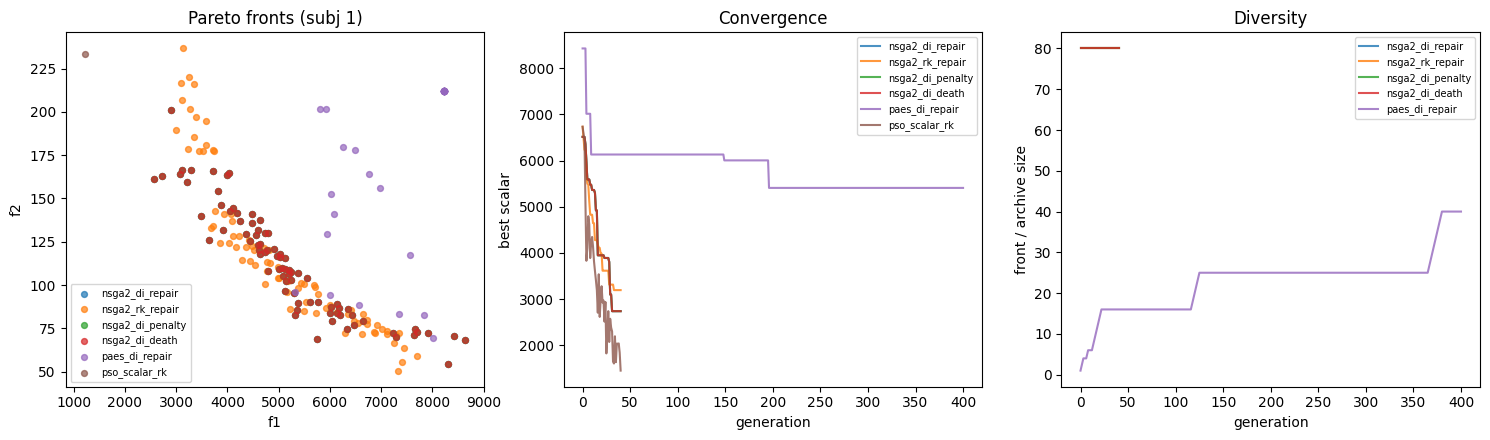

In [13]:
subj1 = next(s for s in subjects if s.sujeto_id == 1)
demo_results = {}
for cfg in plan.configs:
    runner = cfg.runner(); kwargs = cfg.kwargs()
    res = runner(foods, subj1.edad, subj1.calorias, seed=100, **kwargs)
    demo_results[cfg.config_id] = res

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for cid, res in demo_results.items():
    front = np.array(res['front'])
    if len(front):
        axes[0].scatter(front[:,0], front[:,1], label=cid, s=18, alpha=0.7)
axes[0].set_xlabel('f1'); axes[0].set_ylabel('f2'); axes[0].set_title('Pareto fronts (subj 1)')
axes[0].legend(fontsize=7)

for cid, res in demo_results.items():
    trace = res.get('trace', {})
    g = trace.get('generation') or []
    v = trace.get('best_scalar') or trace.get('best_f1') or trace.get('best_sum') or []
    if g and v and len(g) == len(v):
        axes[1].plot(g, v, label=cid, alpha=0.8)
axes[1].set_xlabel('generation'); axes[1].set_ylabel('best scalar')
axes[1].set_title('Convergence'); axes[1].legend(fontsize=7)

for cid, res in demo_results.items():
    trace = res.get('trace', {})
    g = trace.get('generation') or []
    fs = trace.get('front_size') or trace.get('archive_size') or []
    if g and fs and len(g) == len(fs):
        axes[2].plot(g, fs, label=cid, alpha=0.8)
axes[2].set_xlabel('generation'); axes[2].set_ylabel('front / archive size')
axes[2].set_title('Diversity'); axes[2].legend(fontsize=7)

fig.tight_layout()
fig.savefig(EXP_DIR / 'demo_overview.png', dpi=150)
plt.show()


C:\Users\ismadels\AppData\Local\Temp\ipykernel_26552\2737215035.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
C:\Users\ismadels\AppData\Local\Temp\ipykernel_26552\2737215035.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
C:\Users\ismadels\AppData\Local\Temp\ipykernel_26552\2737215035.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
C:\Users\ismadels\AppData\Local\Temp\ipykernel_26552\2737215035.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of b

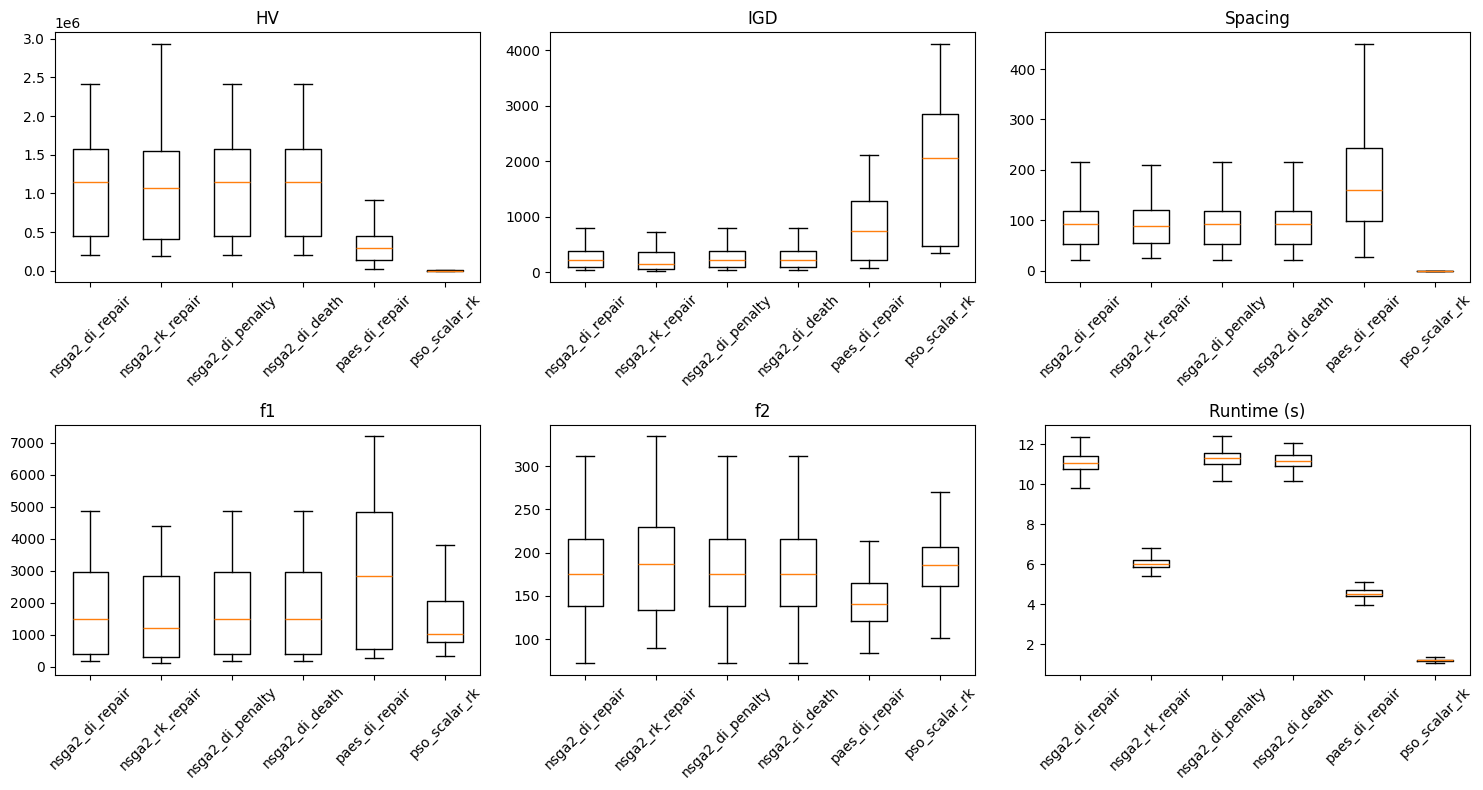

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = [('hypervolume','HV'),('igd','IGD'),('spacing','Spacing'),
           ('f1_best','f1'),('f2_best','f2'),('runtime_s','Runtime (s)')]
for ax, (m, title) in zip(axes.flat, metrics):
    data = [runs[runs.config_id==c][m].dropna().values for c in runs.config_id.unique()]
    labels = list(runs.config_id.unique())
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(title)
fig.tight_layout()
fig.savefig(EXP_DIR / 'boxplots.png', dpi=150)
plt.show()


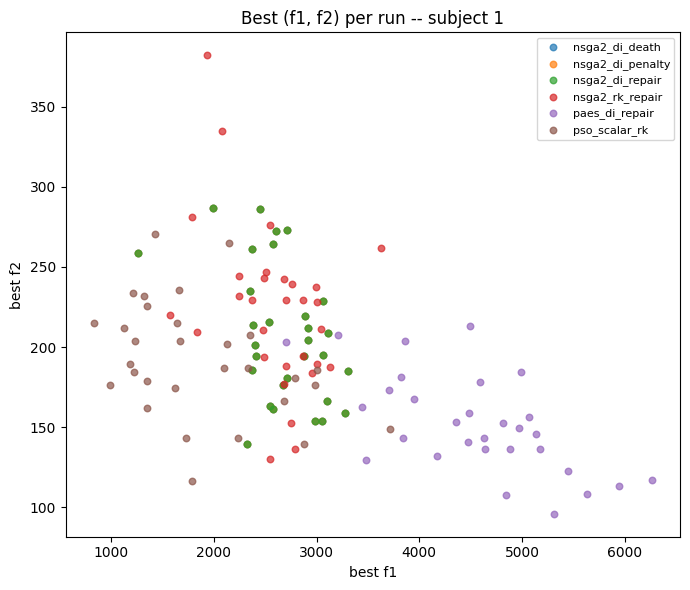

In [15]:
sub1 = runs[runs.subject_id == 1]
fig, ax = plt.subplots(figsize=(7, 6))
for cid, g in sub1.groupby('config_id'):
    ax.scatter(g['f1_best'], g['f2_best'], label=cid, s=22, alpha=0.7)
ax.set_xlabel('best f1'); ax.set_ylabel('best f2')
ax.set_title('Best (f1, f2) per run -- subject 1')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(EXP_DIR / 'best_pts_subject_1.png', dpi=150)
plt.show()


## 6. Sanity checks

Lightweight assertions to catch the most common failure modes:
- Missing or incomplete runs (row counts)
- Mismatched configuration IDs between the plan and the results
- NaNs in the core metrics (HV/IGD/runtime/best objectives)

If these checks pass, the CSVs/figures are typically consistent with what the report expects.

In [16]:
expected = len(plan.configs) * len(subjects) * plan.n_runs
assert len(runs) == expected, f'Unexpected row count: {len(runs)} != {expected}'
assert sorted(runs.config_id.unique()) == sorted([c.config_id for c in plan.configs])
assert runs[['hypervolume','igd','runtime_s','f1_best','f2_best']].notna().all().all()
print('All sanity checks passed.')


All sanity checks passed.
